In [1]:
import pynamicalsys
import numpy as np
import matplotlib.pyplot as plt
import rebound

## First tests

In [2]:
from pynamicalsys import DiscreteDynamicalSystem as dds

In [3]:
ds = dds(model = "logistic map")

In [6]:
x0 = 0.2  # Initial condition for x
r = [2.6, 3.1, 3.5, 3.8]  # List of parameter values

# Generate trajectories for each parameter value (100 iterations each)
trajectories = [
    ds.trajectory(x0, 100, parameters=r[i])
    for i in range(len(r))
]

<Figure size 640x480 with 0 Axes>

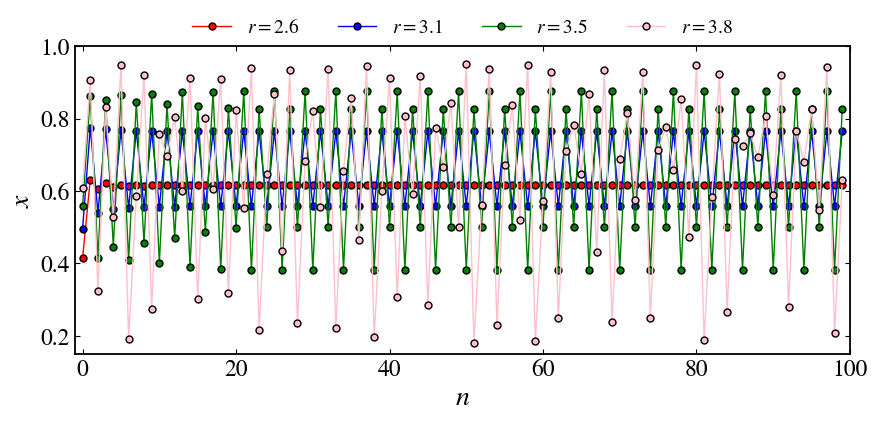

In [ ]:
from pynamicalsys import PlotStyler  # For consistent plot styling
import matplotlib.pyplot as plt  # For plotting

# Apply the plot style
ps = PlotStyler()
ps.apply_style()

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 4))

# Define colors for each trajectory
colors = ["red", "blue", "green", "pink"]

# Plot each trajectory with a different color and label
for i, traj in enumerate(trajectories):
    ax.plot(traj, "-o", color=colors[i], label=f"$r = {r[i]}$")

# Customize the plot labels and limits
plt.xlabel("$n$")  # Iteration index
plt.ylabel("$x$")  # State variable
plt.legend(
    loc="upper center",
    frameon=False,
    ncol=4,
    bbox_to_anchor=(0.5, 1.15)
)
plt.ylim(0.15, 1)
plt.xlim(-1, 100)

plt.show()  # Display the plot

In [10]:
ds.info

{'description': 'Logistic map (1D nonlinear system)',
 'has_jacobian': True,
 'has_backwards_map': False,
 'mapping': CPUDispatcher(<function logistic_map at 0x000001E62A8FAA20>),
 'jacobian': CPUDispatcher(<function logistic_map_jacobian at 0x000001E62A8FACA0>),
 'backwards_mapping': None,
 'dimension': 1,
 'number_of_parameters': 1,
 'parameters': ['r']}

## Implementing my own dynamical system

In [ ]:
# ADDS THE PARENT DIRECTORY TO SYS.PATH
import sys
import os

# Add the project root directory (one level up) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [35]:
from src.integrator.integrate import phi, phi_inv
from src.utils.plotting import plot_position_sitnikov
from scipy.optimize import brentq

In [20]:
e0 = 0.5

# As a test case, we look for periodic orbits that start with some (v,0)
def single_turn_error(v):
    v1, t1 = phi(e = e0, v = v, t = 0)
    return t1 - 2*np.pi

v_per = brentq(f = single_turn_error, a = 0, b = 2.6)

c:\Users\leona\OneDrive - Universitat Politècnica de Catalunya\Desktop\ReboundTests\sitnikov\src\integrator\integrate.py:49: RuntimeWarning: phi function got value v = 0, with t = 0. Check this is intended
  warnings.warn(f"phi function got value v = 0, with t = {t}. Check this is intended", RuntimeWarning)


In [41]:
import importlib
import src.integrator.integrate
importlib.reload(src.integrator.integrate)

<module 'src.integrator.integrate' from 'c:\\Users\\leona\\OneDrive - Universitat Politècnica de Catalunya\\Desktop\\ReboundTests\\sitnikov\\src\\integrator\\integrate.py'>

In [44]:
from numba import njit
# We adapt the function to the expected call signature
@njit
def phi_adapted(state, params):
    v_out, t_out = phi(e=params[0], v=state[0], t=state[1], t_max=params[1])
    return np.array([v_out, t_out])

@njit
def phi_inv_adapted(state, params):
    v_out, t_out = phi_inv(e=params[0], v=state[0], t=state[1], t_max=params[1])
    return np.array([v_out, t_out])

ds_phi = dds(mapping = phi_adapted, backwards_mapping = phi_inv_adapted, system_dimension=2,number_of_parameters=2)

In [43]:
tra0 = ds_phi.trajectory(u = [0.5, 0.5], total_time = 30, parameters = [e0, 100])

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mFailed in nopython mode pipeline (step: nopython frontend)
[1m[1mUntyped global name 'phi':[0m [1m[1mCannot determine Numba type of <class 'function'>[0m
[1m
File "..\..\..\..\..\AppData\Local\Temp\ipykernel_18212\799233312.py", line 5:[0m
[1m<source missing, REPL/exec in use?>[0m
[0m
[0m[1mDuring: Pass nopython_type_inference[0m
[0m[1mDuring: resolving callee type: type(CPUDispatcher(<function phi_adapted at 0x000001E633BF4040>))[0m
[0m[1mDuring: typing of call at c:\Users\leona\miniconda3\envs\reboundenv\Lib\site-packages\pynamicalsys\discrete_time\trajectory_analysis.py (151)[0m
[1m
File "..\..\..\..\..\miniconda3\envs\reboundenv\Lib\site-packages\pynamicalsys\discrete_time\trajectory_analysis.py", line 151:[0m
[1mdef generate_trajectory(
    <source elided>
    for i in range(sample_size):
[1m        state = mapping(state, parameters)
[0m        [1m^[0m[0m

[0m[1mDuring